# Schrödinger's Equation with BSPF

This notebook solves the same linear Schrödinger problem as `pde_schroedinger.ipynb`, but replaces the `py-pde` spatial discretization with `BSPF1D`.

We solve the non-dimensional equation

$$
i \, \partial_t \psi = -\partial_{xx} \psi
$$

on the interval $x \in [0, 20]$ with homogeneous Neumann boundary conditions, so the wave packet reflects off the walls.

## Environment Setup

The next cell makes the notebook runnable directly from the repository checkout without requiring an editable install first.

In [25]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((parent for parent in (cwd, *cwd.parents) if (parent / "pyproject.toml").exists()), cwd)
SRC_ROOT = REPO_ROOT / "src"

for candidate in (SRC_ROOT, REPO_ROOT):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

REPO_ROOT

PosixPath('/Users/moulin/Workspace/pybspf')

## Imports

In [26]:
from math import sqrt

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

from pde import PDE, CartesianGrid, MemoryStorage, ScalarField

from pybspf import BSPF1D

## Grid And Initial Condition

We use the same domain, resolution, and Gaussian wave packet as the reference notebook.

In [27]:
domain = (0.0, 20.0)
num_points = 256
degree = 8
n_basis = 3 * degree
num_boundary_points = degree
reg_param = 1.0e-6

final_time = 2.5
output_dt = 0.001
rk4_dt = 1.0e-3

x = np.linspace(domain[0], domain[1], num_points)
t_eval = np.arange(0.0, final_time + 0.5 * output_dt, output_dt)

psi0 = np.exp(1j * 5.0 * x) * np.exp(-(x - 10.0) ** 2)
psi0 /= sqrt(np.trapezoid(np.abs(psi0) ** 2, x).real)
psi0[:5]

array([3.32293496e-44+0.00000000e+00j, 1.46490460e-43+6.05852984e-44j,
       5.28790415e-43+5.27644776e-43j, 1.33585050e-42+3.21024846e-42j,
       3.46733903e-44+1.59867779e-41j])

## BSPF Spatial Operator

For the Schrödinger equation we only need the second derivative. The BSPF call below uses `k=2` together with homogeneous Neumann boundary data.

In [28]:
dx = x[1] - x[0]


def enforce_zero_flux_neumann_bc(psi: np.ndarray, order: int = 4) -> np.ndarray:
    psi_bc = psi.copy()
    n = len(psi_bc)
    if order >= 4 and n >= 5:
        psi_bc[0] = (48.0 * psi_bc[1] - 36.0 * psi_bc[2] + 16.0 * psi_bc[3] - 3.0 * psi_bc[4]) / 25.0
        psi_bc[-1] = (48.0 * psi_bc[-2] - 36.0 * psi_bc[-3] + 16.0 * psi_bc[-4] - 3.0 * psi_bc[-5]) / 25.0
    elif n >= 3:
        psi_bc[0] = (4.0 * psi_bc[1] - psi_bc[2]) / 3.0
        psi_bc[-1] = (4.0 * psi_bc[-2] - psi_bc[-3]) / 3.0
    else:
        psi_bc[0] = psi_bc[1]
        psi_bc[-1] = psi_bc[-2]
    return psi_bc


operator = BSPF1D.from_grid(
    degree=degree,
    x=x,
    n_basis=n_basis,
    domain=domain,
    use_clustering=True,
    clustering_factor=2.0,
    order=degree,
    num_boundary_points=num_boundary_points,
    correction="spectral",
)


def schrodinger_rhs(t: float, psi: np.ndarray) -> np.ndarray:
    psi_bc = enforce_zero_flux_neumann_bc(psi, order=4)
    d2psi_dx2, _ = operator.differentiate(psi_bc, k=2, lam=reg_param, neumann_bc=(0.0, 0.0))
    return 1j * d2psi_dx2

## Time Integration

We evolve the pybspf discretization with `solve_ivp`, storing the solution on the same regular output times used by the reference example.

In [29]:
psi0 = enforce_zero_flux_neumann_bc(psi0, order=4)

solution = solve_ivp(
    schrodinger_rhs,
    t_span=(t_eval[0], t_eval[-1]),
    y0=psi0,
    t_eval=t_eval,
    method="RK45",
    max_step=rk4_dt,
    rtol=1.0e-10,
    atol=1.0e-10,
)
if not solution.success:
    raise RuntimeError(f"solve_ivp failed: {solution.message}")

psi_history = np.array([
    enforce_zero_flux_neumann_bc(psi, order=4)
    for psi in solution.y.T
])

density_history = np.abs(psi_history) ** 2
density_history.shape

(2501, 256)

## Diagnostics

The continuous equation conserves the $L^2$ norm, so we monitor the discrete mass over time.

In [30]:
mass_history = np.trapezoid(density_history, x, axis=1)
mass_history[:5], mass_history[-5:]

(array([1., 1., 1., 1., 1.]),
 array([0.99893551, 0.99893419, 0.99893288, 0.99893158, 0.99893029]))

## Plot

We compare the py-pde reference solve and the BSPF solve using the same kymograph layout for $|\psi|^2$. Notice that it require a much smaller timestep (dt/16) to run.

In [31]:
grid_pde = CartesianGrid([[domain[0], domain[1]]], num_points, periodic=False)
initial_state_pde = ScalarField(grid_pde, data=psi0.copy())

eq_pde = PDE({"ψ": "I * laplace(ψ)"}, bc={"derivative": 0})

storage_pde = MemoryStorage()
eq_pde.solve(
    initial_state_pde,
    t_range=final_time,
    dt=rk4_dt/16,
    tracker=[storage_pde.tracker(output_dt)],
)

t_pde = np.array(storage_pde.times)
density_history_pde = np.array([np.abs(field.data) ** 2 for field in storage_pde])

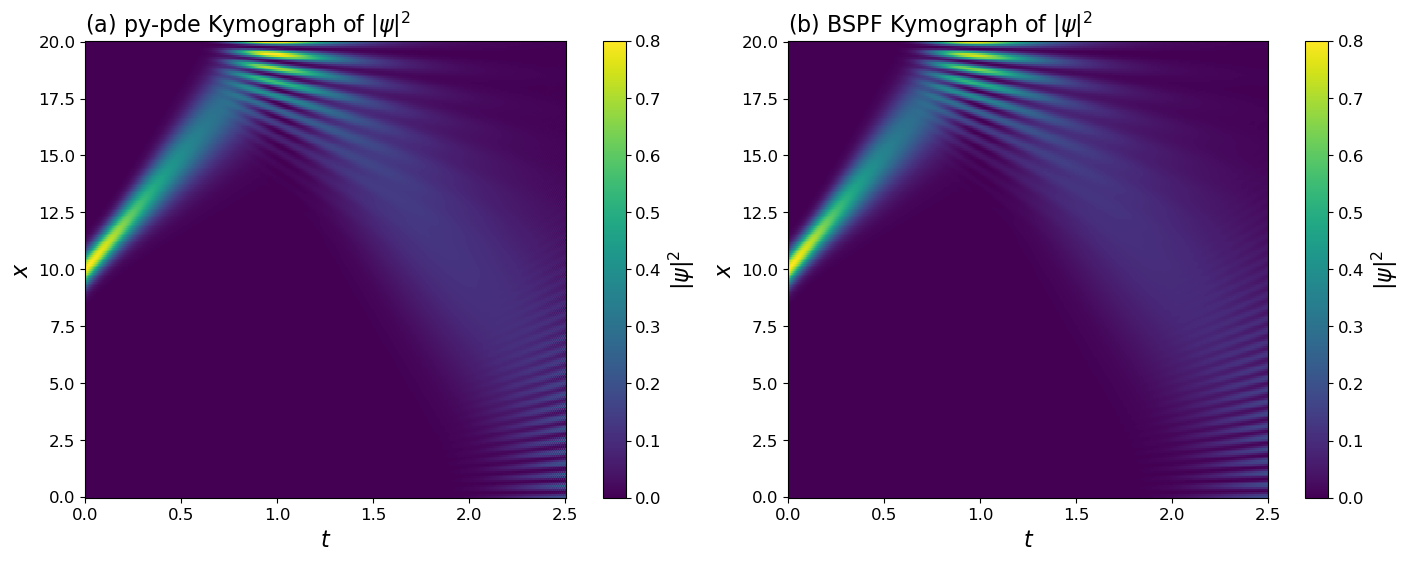

In [32]:

plt.rcParams.update(
    {
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.titlesize": 16,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

image = axes[0].pcolormesh(t_pde, x, density_history_pde.T, shading="auto", vmin=0.0, vmax=0.8)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$x$")
axes[0].set_title("(a) py-pde Kymograph of $|\\psi|^2$", loc="left")
fig.colorbar(image, ax=axes[0], label="$|\\psi|^2$")

image = axes[1].pcolormesh(t_eval, x, density_history.T, shading="auto", vmin=0.0, vmax=0.8)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("$x$")
axes[1].set_title("(b) BSPF Kymograph of $|\\psi|^2$", loc="left")
fig.colorbar(image, ax=axes[1], label="$|\\psi|^2$")

plt.show()